In [87]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="5" color="black">ch07_2. 다중 클래스 분류 (와인품질등급예측)</font>

# 레드 와인 품질 등급 예측
```
1. 데이터셋 확보 & 전처리
    결측치 처리 >> 독립변수와 종속변수 분리 >> 독립변수의 스케일 조정(std) >> 종속변수의 균형 확인
    >> 종속변수 원-핫 인코딩(get_dummies) >> 훈련 데이터셋과 검증 데이터셋 분리(train_test_split)
2. 모델 구성
3. 모델 학습과정 설정 (다중 분류)
4. 모델 학습 (callbacks, compute_class_weight 활용)
5. 모델 평가 (시각화, 평가, 교차표)
6. 모델 사용 (저장, 예측)
```

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.layers import ReLU, ELU, LeakyReLU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal # 카이밍 초기화

from tensorflow.keras.callbacks import Callback, ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.metrics import Recall, Precision
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix

## 1. 데이터셋 확보 및 전처리
- 독립변수와 종속변수 분리
- 독립변수의 스케일 조정(std)
- 종속변수의 균형 확인
- 종속변수 원-핫 인코딩(get_dummies)
- 훈련 데이터셋과 검증 데이터셋 분리(train_test_split)

In [8]:
redwine = pd.read_csv('data/winequality-red.csv', delimiter=';')
redwine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [16]:
# 독립변수와 종속변수 분리
X_redwine = redwine.iloc[:,:-1].to_numpy()
y_redwine = redwine.iloc[:,-1]
X_redwine.shape, y_redwine.shape

((1599, 11), (1599,))

In [17]:
# 독립변수의 스케일 조정
scaler = StandardScaler()

redwine_X = scaler.fit_transform(X_redwine)

In [20]:
# 종속변수의 원-핫 인코딩
redwine_Y = pd.get_dummies(y_redwine)

In [19]:
# 종속변수의 균형 확인
y_redwine.value_counts(normalize=True)

5    0.425891
6    0.398999
7    0.124453
4    0.033146
8    0.011257
3    0.006254
Name: quality, dtype: float64

In [21]:
# 독립변수와 타겟변수
redwine_X.shape, redwine_Y.shape

((1599, 11), (1599, 6))

In [22]:
# 훈련 데이터셋과 검증 데이터셋 분리
X_train, X_test, Y_train, Y_test = train_test_split(redwine_X, redwine_Y, test_size=0.3, stratify=redwine_Y, random_state=12)

In [23]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((1119, 11), (480, 11), (1119, 6), (480, 6))

## 2. 모델 구성
- 입력 : 11 >> 64 >> 50 >> 30 >> 출력 : 6
- ReLU 활성화 함수와 He Normal 가중치 초기화 : '가중치 소멸'과 '신호의 폭주/줄어듦'을 방지

In [82]:
model = Sequential(name='redwine_seq')
model.add(Input(shape=(11,)))

model.add(Dense(units=128, activation='elu', kernel_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=64, activation='relu', kernel_initializer=HeNormal(seed=42)))
model.add(Dropout(0.3))

model.add(Dense(units=32, activation='relu', kernel_initializer='he_normal')) # relu를 사용할 때, he_normal을 함께 사용
model.add(Dropout(0.3))

model.add(Dense(units=16, activation='elu', kernel_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=6, activation='softmax'))
model.summary()

Model: "redwine_seq"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_32 (Dense)            (None, 128)               1536      
                                                                 
 batch_normalization_1 (Batc  (None, 128)              512       
 hNormalization)                                                 
                                                                 
 dropout_10 (Dropout)        (None, 128)               0         
                                                                 
 dense_33 (Dense)            (None, 64)                8256      
                                                                 
 dropout_11 (Dropout)        (None, 64)                0         
                                                                 
 dense_34 (Dense)            (None, 32)                2080      
                                                       

## 3. 모델 학습과정 설정

In [83]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy', Recall(name='recall'), Precision(name='precision')])

## 4. 모델 학습
- callbacks 활용

In [84]:
%%time
earlystop = EarlyStopping(monitor='val_loss', patience=50, verbose=0)

hist = model.fit(X_train, Y_train,
                epochs=200,
                batch_size=128,
                validation_split=0.2,
                callbacks=[earlystop],
                verbose=1)

Epoch 1/200
7/7 [==============================] - 1s 33ms/step - loss: 2.8525 - accuracy: 0.1922 - recall: 0.0726 - precision: 0.1935 - val_loss: 2.1494 - val_accuracy: 0.2500 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00
Epoch 2/200
7/7 [==============================] - 0s 6ms/step - loss: 2.6630 - accuracy: 0.2235 - recall: 0.0905 - precision: 0.2447 - val_loss: 2.0649 - val_accuracy: 0.3884 - val_recall: 0.0045 - val_precision: 0.3333
Epoch 3/200
7/7 [==============================] - 0s 8ms/step - loss: 2.5769 - accuracy: 0.2682 - recall: 0.0983 - precision: 0.2643 - val_loss: 2.0009 - val_accuracy: 0.4330 - val_recall: 0.0089 - val_precision: 0.5000
Epoch 4/200
7/7 [==============================] - 0s 6ms/step - loss: 2.3985 - accuracy: 0.2726 - recall: 0.1084 - precision: 0.3129 - val_loss: 1.9494 - val_accuracy: 0.4688 - val_recall: 0.0134 - val_precision: 0.6000
Epoch 5/200
7/7 [==============================] - 0s 7ms/step - loss: 2.3516 - accuracy: 0.3039 - recall: 

Epoch 38/200
7/7 [==============================] - 0s 7ms/step - loss: 1.4679 - accuracy: 0.5654 - recall: 0.3229 - precision: 0.5898 - val_loss: 1.3729 - val_accuracy: 0.5670 - val_recall: 0.2768 - val_precision: 0.7294
Epoch 39/200
7/7 [==============================] - 0s 7ms/step - loss: 1.4333 - accuracy: 0.5754 - recall: 0.3363 - precision: 0.6501 - val_loss: 1.3652 - val_accuracy: 0.5625 - val_recall: 0.2902 - val_precision: 0.7222
Epoch 40/200
7/7 [==============================] - 0s 6ms/step - loss: 1.3984 - accuracy: 0.5944 - recall: 0.3374 - precision: 0.6358 - val_loss: 1.3565 - val_accuracy: 0.5670 - val_recall: 0.2946 - val_precision: 0.7253
Epoch 41/200
7/7 [==============================] - 0s 6ms/step - loss: 1.4211 - accuracy: 0.5698 - recall: 0.3307 - precision: 0.6091 - val_loss: 1.3464 - val_accuracy: 0.5536 - val_recall: 0.3036 - val_precision: 0.7391
Epoch 42/200
7/7 [==============================] - 0s 8ms/step - loss: 1.4059 - accuracy: 0.5810 - recall: 0.34

Epoch 75/200
7/7 [==============================] - 0s 8ms/step - loss: 1.1619 - accuracy: 0.5821 - recall: 0.4358 - precision: 0.6220 - val_loss: 1.1658 - val_accuracy: 0.5491 - val_recall: 0.4464 - val_precision: 0.5814
Epoch 76/200
7/7 [==============================] - 0s 7ms/step - loss: 1.1331 - accuracy: 0.6000 - recall: 0.4447 - precision: 0.6430 - val_loss: 1.1633 - val_accuracy: 0.5625 - val_recall: 0.4509 - val_precision: 0.5838
Epoch 77/200
7/7 [==============================] - 0s 7ms/step - loss: 1.1011 - accuracy: 0.6056 - recall: 0.4503 - precision: 0.6542 - val_loss: 1.1605 - val_accuracy: 0.5625 - val_recall: 0.4509 - val_precision: 0.5906
Epoch 78/200
7/7 [==============================] - 0s 7ms/step - loss: 1.1327 - accuracy: 0.5855 - recall: 0.4402 - precision: 0.6264 - val_loss: 1.1576 - val_accuracy: 0.5714 - val_recall: 0.4554 - val_precision: 0.5930
Epoch 79/200
7/7 [==============================] - 0s 7ms/step - loss: 1.1293 - accuracy: 0.6022 - recall: 0.45

Epoch 112/200
7/7 [==============================] - 0s 9ms/step - loss: 1.0200 - accuracy: 0.6134 - recall: 0.5006 - precision: 0.6559 - val_loss: 1.0897 - val_accuracy: 0.5625 - val_recall: 0.4732 - val_precision: 0.5922
Epoch 113/200
7/7 [==============================] - 0s 7ms/step - loss: 1.0262 - accuracy: 0.6145 - recall: 0.4827 - precision: 0.6297 - val_loss: 1.0849 - val_accuracy: 0.5625 - val_recall: 0.4866 - val_precision: 0.5989
Epoch 114/200
7/7 [==============================] - 0s 7ms/step - loss: 1.0283 - accuracy: 0.6123 - recall: 0.5106 - precision: 0.6401 - val_loss: 1.0828 - val_accuracy: 0.5580 - val_recall: 0.4911 - val_precision: 0.5946
Epoch 115/200
7/7 [==============================] - 0s 5ms/step - loss: 1.0065 - accuracy: 0.6089 - recall: 0.5073 - precision: 0.6376 - val_loss: 1.0824 - val_accuracy: 0.5536 - val_recall: 0.4821 - val_precision: 0.5967
Epoch 116/200
7/7 [==============================] - 0s 7ms/step - loss: 1.0439 - accuracy: 0.5978 - recall:

Epoch 149/200
7/7 [==============================] - 0s 8ms/step - loss: 0.9447 - accuracy: 0.6235 - recall: 0.5162 - precision: 0.6462 - val_loss: 1.0525 - val_accuracy: 0.5804 - val_recall: 0.4732 - val_precision: 0.5730
Epoch 150/200
7/7 [==============================] - 0s 11ms/step - loss: 0.9486 - accuracy: 0.6190 - recall: 0.5274 - precision: 0.6439 - val_loss: 1.0463 - val_accuracy: 0.5580 - val_recall: 0.4955 - val_precision: 0.5842
Epoch 151/200
7/7 [==============================] - 0s 9ms/step - loss: 0.9620 - accuracy: 0.6156 - recall: 0.5251 - precision: 0.6564 - val_loss: 1.0417 - val_accuracy: 0.5536 - val_recall: 0.5000 - val_precision: 0.5895
Epoch 152/200
7/7 [==============================] - 0s 8ms/step - loss: 0.9498 - accuracy: 0.6156 - recall: 0.5162 - precision: 0.6498 - val_loss: 1.0424 - val_accuracy: 0.5491 - val_recall: 0.4821 - val_precision: 0.5870
Epoch 153/200
7/7 [==============================] - 0s 8ms/step - loss: 0.9902 - accuracy: 0.6101 - recall

Epoch 186/200
7/7 [==============================] - 0s 7ms/step - loss: 0.9256 - accuracy: 0.6201 - recall: 0.5341 - precision: 0.6486 - val_loss: 1.0468 - val_accuracy: 0.5491 - val_recall: 0.4866 - val_precision: 0.5619
Epoch 187/200
7/7 [==============================] - 0s 8ms/step - loss: 0.9389 - accuracy: 0.6168 - recall: 0.5285 - precision: 0.6366 - val_loss: 1.0405 - val_accuracy: 0.5446 - val_recall: 0.4866 - val_precision: 0.5677
Epoch 188/200
7/7 [==============================] - 0s 7ms/step - loss: 0.9297 - accuracy: 0.6223 - recall: 0.5453 - precision: 0.6550 - val_loss: 1.0339 - val_accuracy: 0.5536 - val_recall: 0.4866 - val_precision: 0.5677
Epoch 189/200
7/7 [==============================] - 0s 7ms/step - loss: 0.9235 - accuracy: 0.6291 - recall: 0.5352 - precision: 0.6589 - val_loss: 1.0322 - val_accuracy: 0.5446 - val_recall: 0.4866 - val_precision: 0.5648
Epoch 190/200
7/7 [==============================] - 0s 6ms/step - loss: 0.9020 - accuracy: 0.6313 - recall:

## 5. 모델 평가

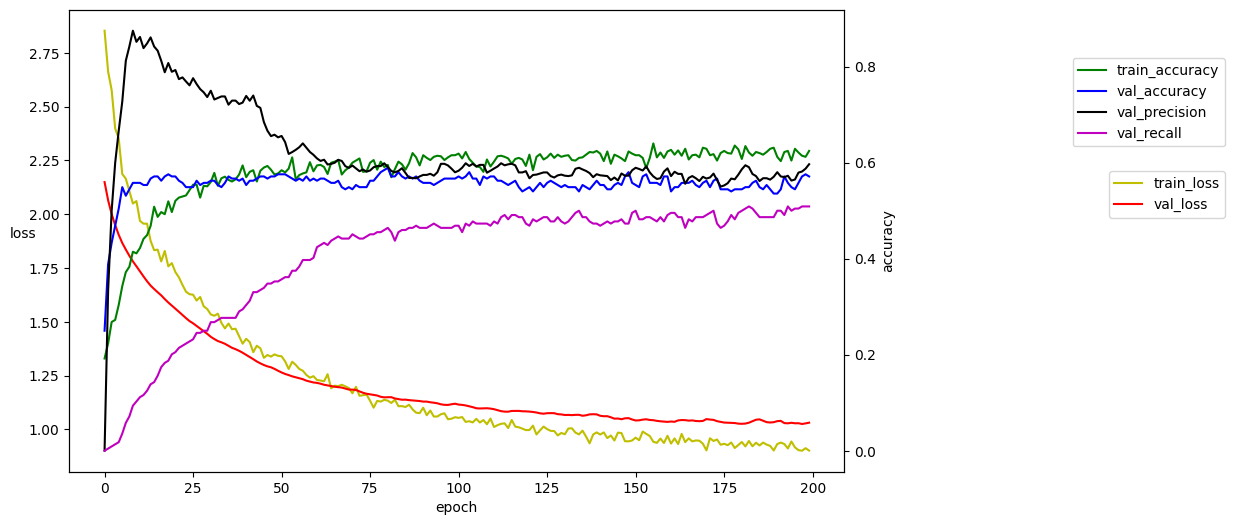

In [86]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss', rotation=0)

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.plot(hist.history['val_precision'], 'k', label='val_precision')
acc_ax.plot(hist.history['val_recall'], 'm', label='val_recall')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.6), ncol=1)
acc_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.8), ncol=1)
plt.show()

In [51]:
loss, accuracy, recall, precision = model.evaluate(X_test, Y_test, verbose=0)

In [53]:
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"정확도 : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"정밀도 : {precision:.4f} ({precision*100:.2f}%)")
print(f"재현율 : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score : {f1_score:.4f} ({f1_score*100:.2f}%)")

정확도 : 0.6354 (63.54%)
정밀도 : 0.6667 (66.67%)
재현율 : 0.5125 (51.25%)
F1-Score : 0.5795 (57.95%)


In [67]:
y_hat = model.predict(X_test).argmax(axis=1) + 3
y_test = Y_test.values.argmax(axis=1) + 3

15/15 [==============================] - 0s 426us/step


In [69]:
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,5,6,7
실제값,,,
3,2,1,0
4,10,5,1
5,157,43,4
6,57,123,12
7,4,31,25
8,0,4,1


## 6. 모델 사용

In [76]:
X_redwine[0]

array([ 7.4   ,  0.7   ,  0.    ,  1.9   ,  0.076 , 11.    , 34.    ,
        0.9978,  3.51  ,  0.56  ,  9.4   ])

In [77]:
data = [[ 7.4,  0.7,  0,  1.9,  0.076, 11, 34,0.9978,  3.51,  0.56,  9.4]]
input_data = scaler.transform(data)
model.predict(input_data).argmax(axis=1) + 3

1/1 [==============================] - 0s 64ms/step


array([5], dtype=int64)